# Unit Root Tests — Lab Session

---

In this lab we will:
1. Pull US CPI inflation data from FRED
2. Visualize the series and its ACF/PACF
3. Run the **Dickey-Fuller (DF)** and **Augmented Dickey-Fuller (ADF)** tests
4. Compare intercept-only vs. intercept-and-trend specifications


## 0. Setup

Install / import the required libraries.

In [2]:
# Uncomment if running for the first time
# !pip install pandas-datareader statsmodels matplotlib --quiet

from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

---
## 1. Download US CPI Inflation from FRED

We use **CPIAUCSL** (Consumer Price Index, All Urban Consumers, Seasonally Adjusted) at monthly frequency and compute the **month-over-month percent change** as our inflation series

In [8]:
# ── Download CPI from FRED ──────────────────────────────────────────────────
fred = Fred(api_key='e7d91fd4ac05e8ae87fa956d551f861f')

cpi = fred.get_series('CPIAUCSL', observation_start='1960-01-01', observation_end='2023-12-31')
cpi = cpi.to_frame()
cpi.columns = ['CPI']

# Month-over-month inflation (percentage points)
inflation = cpi['CPI'].pct_change() * 100
inflation = inflation.dropna()
inflation.name = 'Inflation'

print(inflation)

1960-02-01    0.136193
1960-03-01    0.000000
1960-04-01    0.442027
1960-05-01    0.101557
1960-06-01    0.135272
                ...   
2023-08-01    0.483571
2023-09-01    0.390092
2023-10-01    0.136685
2023-11-01    0.146898
2023-12-01    0.192440
Name: Inflation, Length: 767, dtype: float64


---
## 2. Plot the Series

> **Key question before testing:** Does the series look like it has a deterministic trend, a stochastic trend, or neither?  
> The answer guides which DF specification to use (intercept-only vs. intercept + trend).

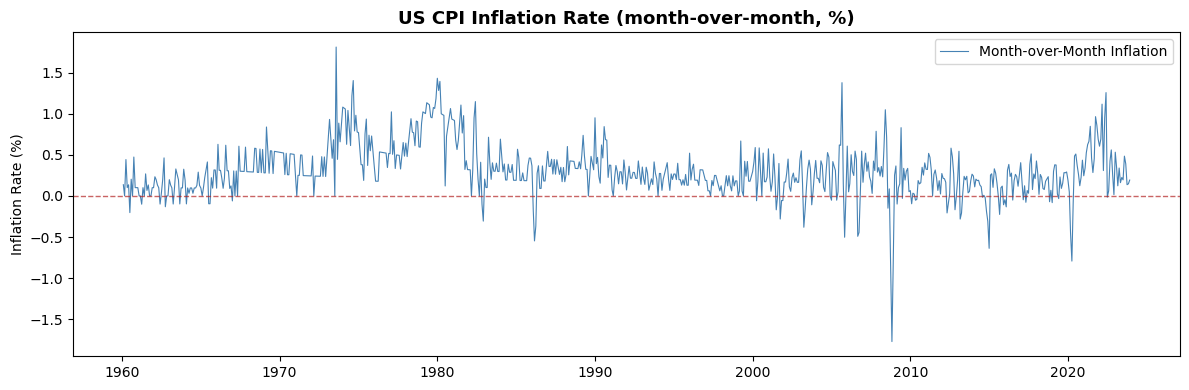

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(inflation.index, inflation.values, color='steelblue', linewidth=0.8, label='Month-over-Month Inflation')
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('US CPI Inflation Rate (month-over-month, %)', fontsize=13, fontweight='bold')
ax.set_ylabel('Inflation Rate (%)')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. ACF and PACF

The autocorrelation function (ACF) of a **unit root process** decays very slowly — autocorrelations stay near 1 for many lags. A **stationary but persistent** AR process decays geometrically. Plotting both helps us form a prior before testing.

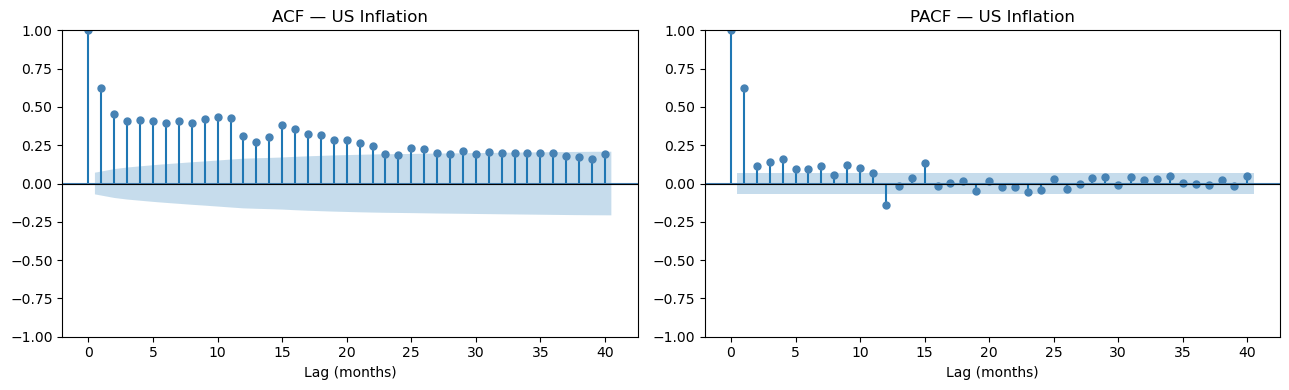

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_acf(inflation, lags=40, ax=axes[0], color='steelblue', title='ACF — US Inflation')
plot_pacf(inflation, lags=40, ax=axes[1], color='steelblue', title='PACF — US Inflation', method='ywm')

for ax in axes:
    ax.set_xlabel('Lag (months)')
    ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 4. Simple (1-Lag) Dickey-Fuller Test

The **benchmark DF test** regresses:

$$\Delta y_t = \mu + \alpha y_{t-1} + \varepsilon_t$$

and tests $H_0: \alpha = 0$ (unit root) vs $H_1: \alpha < 0$ (stationary).  
Under $H_0$ the t-statistic **does not follow a standard Normal** — we use Dickey-Fuller critical values.

| Specification | 10% | 5% | 1% |
|---|---|---|---|
| Intercept only | -2.57 | -2.86 | -3.43 |
| Intercept + trend | -3.12 | -3.41 | -3.96 |

In [15]:
# Simple DF: maxlags=0 forces no augmentation (1-lag benchmark)
df_result = adfuller(inflation, maxlag=0, regression='c', autolag=None)

print('=' * 55)
print('  Simple Dickey-Fuller Test (intercept only, 1 lag)')
print('=' * 55)
print(f'  Test statistic : {df_result[0]:.4f}')
print(f'  p-value        : {df_result[1]:.4f}')
print(f'  Lags used      : {df_result[2]}')
print(f'  Observations   : {df_result[3]}')
print('  Critical Values:')
for key, val in df_result[4].items():
    print(f'    {key}: {val:.4f}')
print('=' * 55)

if df_result[0] < df_result[4]['5%']:
    print('  → REJECT H0 at 5%: evidence against unit root')
else:
    print('  → FAIL TO REJECT H0 at 5%: cannot rule out unit root')

  Simple Dickey-Fuller Test (intercept only, 1 lag)
  Test statistic : -13.3725
  p-value        : 0.0000
  Lags used      : 0
  Observations   : 766
  Critical Values:
    1%: -3.4389
    5%: -2.8653
    10%: -2.5688
  → REJECT H0 at 5%: evidence against unit root


---
## 5. Augmented Dickey-Fuller (ADF) Test

The simple DF test is misspecified if there is serial correlation in the errors. The **ADF** adds lags of $\Delta y_t$ to absorb this:

$$\Delta y_t = \mu + \alpha y_{t-1} + \gamma_1 \Delta y_{t-1} + \cdots + \gamma_{p-1} \Delta y_{t-p+1} + \varepsilon_t$$

We still look at the t-statistic on $\alpha$ and use the same DF critical values.

**Lag selection:** we use AIC (as in the lecture slides example with max 8 lags).

In [19]:
def run_adf(series, regression='c', maxlags=12, label=''):
    """Run ADF test and print a clean summary."""
    result = adfuller(series, maxlag=maxlags, regression=regression, autolag='AIC')
    spec = {'c': 'Intercept only', 'ct': 'Intercept + trend', 'n': 'No constant'}[regression]
    print(f'\n{"-"*58}')
    print(f'  ADF Test — {spec}  {label}')
    print(f'{"-"*58}')
    print(f'  Test statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Lags selected  : {result[2]}  (AIC, max={maxlags})')
    print(f'  Observations   : {result[3]}')
    print(f'  Critical Values:')
    for k, v in result[4].items():
        reject = '← reject H0' if result[0] < v else ''
        print(f'    {k}: {v:.4f}  {reject}')
    conclusion = 'REJECT H0' if result[1] < 0.05 else 'FAIL TO REJECT H0'
    print(f'  → {conclusion} at 5% (p = {result[1]:.4f})')
    return result

# ── Intercept only ──────────────────────────────────────────────────────────
adf_c  = run_adf(inflation, regression='c',  maxlags=12, label='[US Inflation]')

# ── Intercept + trend ───────────────────────────────────────────────────────
adf_ct = run_adf(inflation, regression='ct', maxlags=12, label='[US Inflation]')


----------------------------------------------------------
  ADF Test — Intercept only  [US Inflation]
----------------------------------------------------------
  Test statistic : -3.6802
  p-value        : 0.0044
  Lags selected  : 11  (AIC, max=12)
  Observations   : 755
  Critical Values:
    1%: -3.4390  ← reject H0
    5%: -2.8654  ← reject H0
    10%: -2.5688  ← reject H0
  → REJECT H0 at 5% (p = 0.0044)

----------------------------------------------------------
  ADF Test — Intercept + trend  [US Inflation]
----------------------------------------------------------
  Test statistic : -3.9372
  p-value        : 0.0108
  Lags selected  : 11  (AIC, max=12)
  Observations   : 755
  Critical Values:
    1%: -3.9708  
    5%: -3.4163  ← reject H0
    10%: -3.1305  ← reject H0
  → REJECT H0 at 5% (p = 0.0108)


---
## 6. Sub-sample Analysis

The lecture notes flag that inflation is a **debated case** , and results can change with the sample. The Great Inflation (1970s) and post-2021 episode are notable outliers. Let's check stability.

In [22]:
subsamples = {
    'Full (1960–2024)' : inflation,
    'Pre-Volcker (1960–1982)' : inflation[:'1982'],
    'Great Moderation (1984–2019)': inflation['1984':'2019'],
    'Post-GFC (2010–2024)' : inflation['2010':],
}

print('\nADF Test Comparison Across Sub-samples (intercept only, AIC lags, max=12)')
print(f'{"Sample":<35} {"Stat":>8} {"p-val":>8} {"Lags":>6} {"Decision (5%)":<25}')
print('-' * 88)

for name, series in subsamples.items():
    res = adfuller(series.dropna(), maxlag=12, regression='c', autolag='AIC')
    decision = 'Reject H0 (stationary)' if res[1] < 0.05 else 'Fail to Reject (unit root?)'
    print(f'{name:<35} {res[0]:>8.4f} {res[1]:>8.4f} {res[2]:>6}  {decision}')


ADF Test Comparison Across Sub-samples (intercept only, AIC lags, max=12)
Sample                                  Stat    p-val   Lags Decision (5%)            
----------------------------------------------------------------------------------------
Full (1960–2024)                     -3.6802   0.0044     11  Reject H0 (stationary)
Pre-Volcker (1960–1982)              -1.4884   0.5392      8  Fail to Reject (unit root?)
Great Moderation (1984–2019)         -5.5544   0.0000     11  Reject H0 (stationary)
Post-GFC (2010–2024)                 -2.6422   0.0846      6  Fail to Reject (unit root?)
